In [ ]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

full_dictionary = {}
with open('../../source_data/61k_classified_apps_deberta_multi_v2_not_in_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        full_dictionary[obj['app_id']] = obj['category']

with open('../../source_data/61k_app_categories_from_playstore.jsonl', 'r') as file:
    for line in file:
        obj = json.loads(line.strip())
        full_dictionary[obj['app_id']] = obj['genre']

In [ ]:
category_dict_not_in_playstore = {}
category_dict_from_playstore = {}

category_dict_sources = {
    "Not in Play Store": category_dict_not_in_playstore,
    "Not updated for 2+ yrs": category_dict_from_playstore,
}

app_categories = {}

with open('../../source_data/61k_app_installs.json', 'r') as file: 
    tmp = json.load(file)

for record in tmp:
    source_tmp = record["source"]
    app_id = record["package_name"]

    if source_tmp == "AndroZoo":
        source = "Not in Play Store"
        category_dict_not_in_playstore[record["package_name"]] = full_dictionary[record["package_name"]]
    elif source_tmp == "Play Store":
        category_dict_from_playstore[record["package_name"]] = full_dictionary[record["package_name"]]


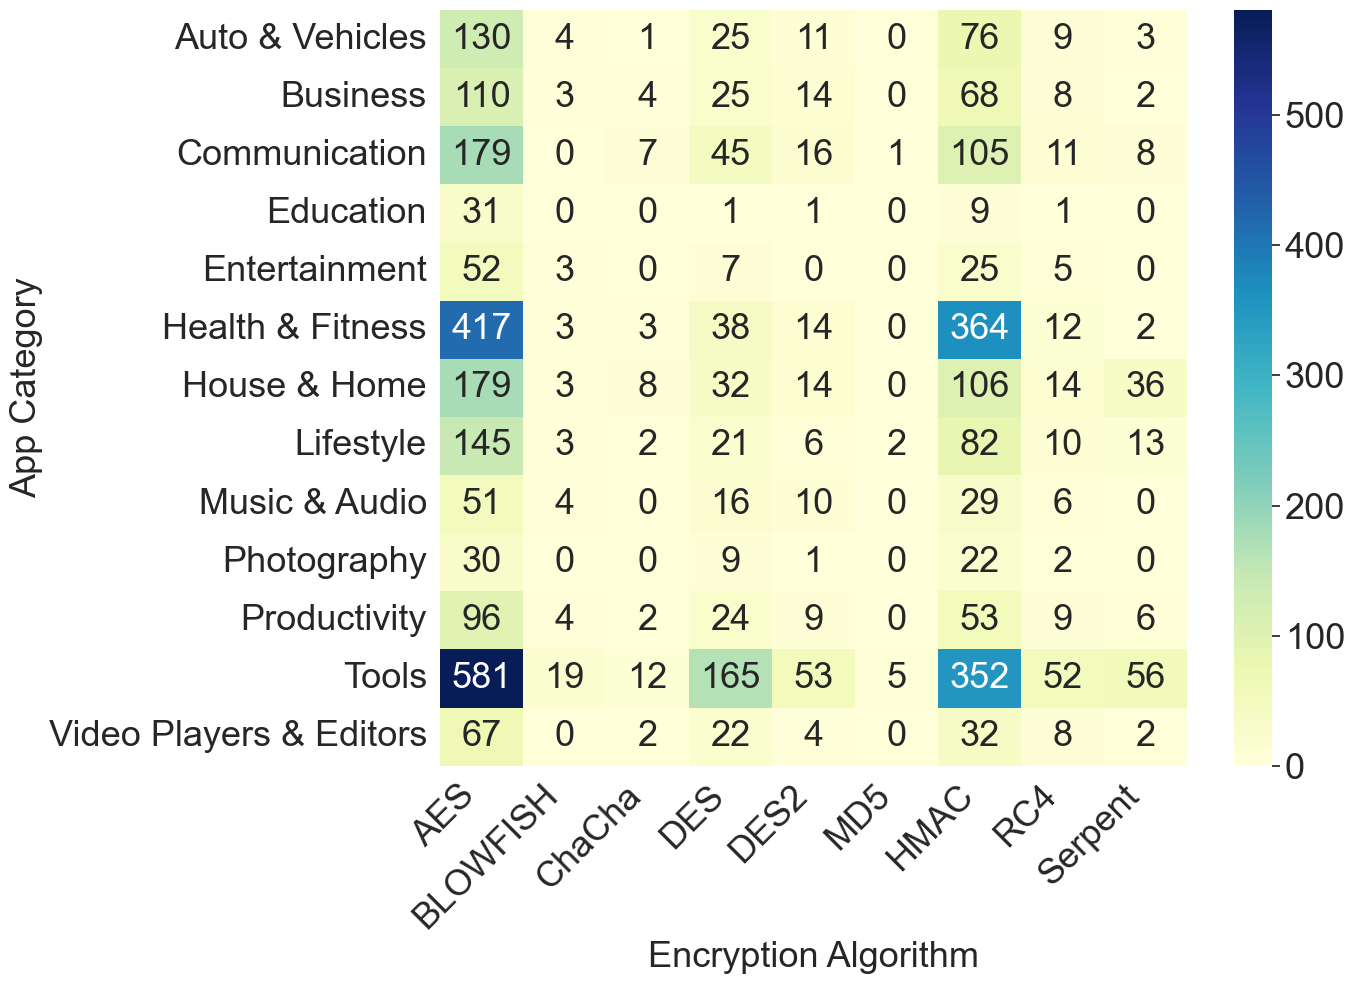

Heatmap saved as plot/vsa_crypto_heatmap_in_playstore.pdf


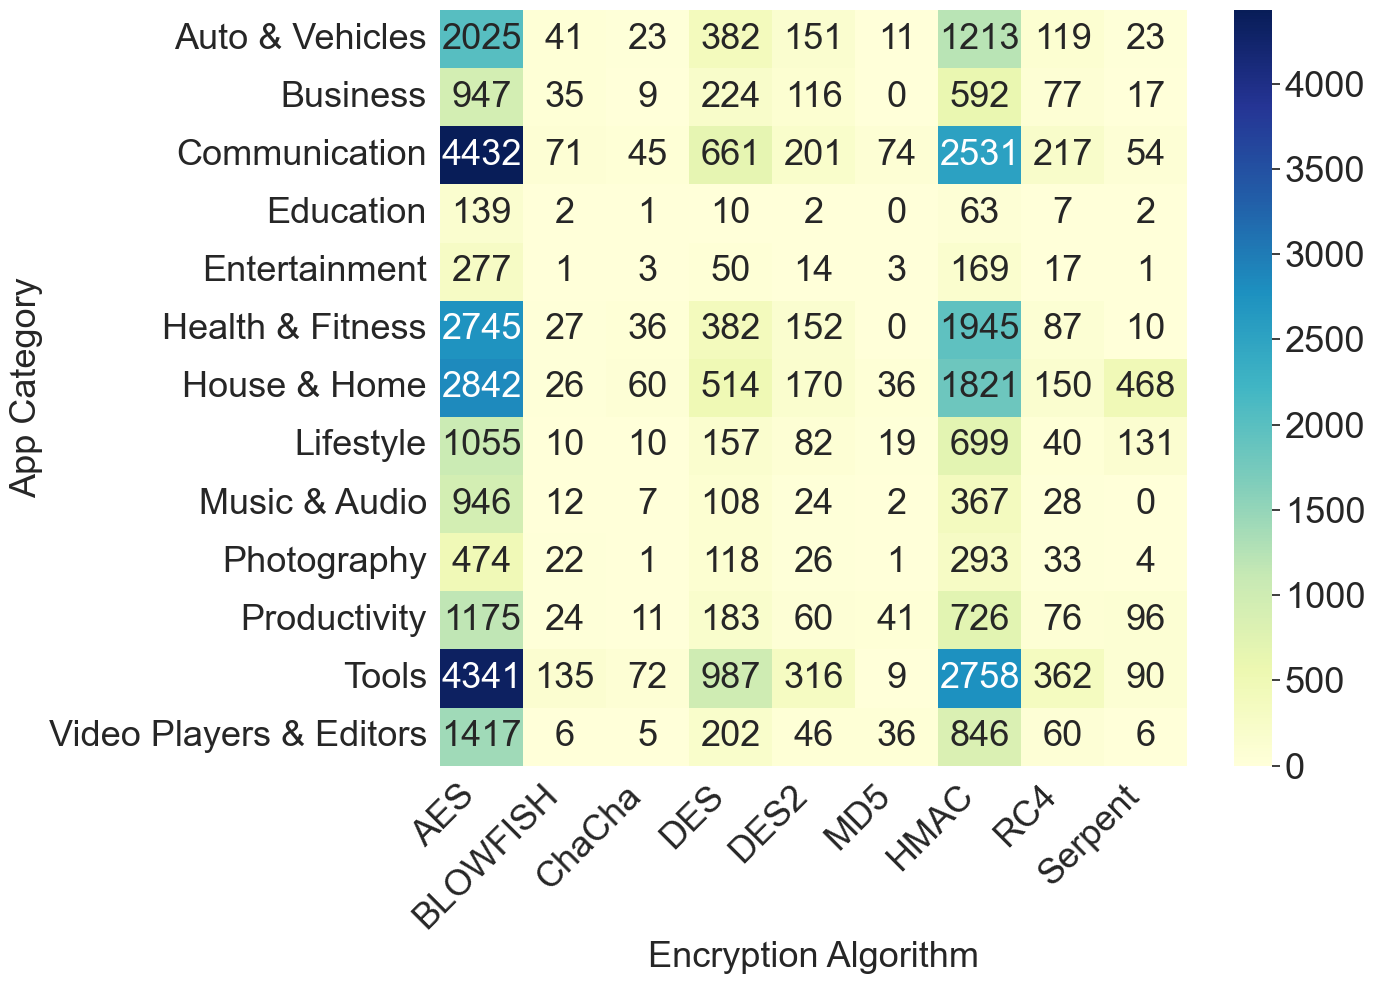

Heatmap saved as plot/vsa_crypto_heatmap_not_in_playstore.pdf


In [ ]:
def generate_heatmap(crypto_results_file, app_metadata_file,
                      output_image='plot/vsa_crypto_heatmap.pdf', title=None):

    font_size = 26 
    # font = {#'family' : 'normal',
    #     'size'   : 26}
    # matplotlib.rc('font', **font)
    # plt.rcParams.update({'font.size': 26}) # Sets default for everything

    # 1. Load the crypto analysis results
    with open(crypto_results_file, 'r') as f:
        crypto_data = json.load(f)

    # 3. Prepare data for the heatmap
    heatmap_data = []
    
    for app in crypto_data.get('apps', []):
        app_id = app.get('app_name')
        category = app_metadata_file.get(app_id)
        
        # Only process apps that belong to this source (metadata file)
        if category:
            for alg in app.get('encryption_algs', []):
                heatmap_data.append({
                    'Category': category,
                    'Algorithm': alg
                })

    df = pd.DataFrame(heatmap_data)

    if df.empty:
        print(f"No matching data found between crypto results and app categories for {app_metadata_file}.")
        return

    # 4. Create a pivot table for counting occurrences
    # This creates a matrix where Rows = Category, Columns = Algorithm
    pivot_table = df.pivot_table(index='Category', 
                                 columns='Algorithm', 
                                 aggfunc='size', 
                                 fill_value=0)

    # --- MODIFY THIS SECTION ---

    # Define the specific rows and columns you want
    selected_categories = ['Auto & Vehicles', 'Business', 'Communication', 'Education', 'Entertainment', 'Health & Fitness', 
                           'House & Home', 'Lifestyle', 'Music & Audio', 'Photography', 'Productivity', 'Tools', 'Video Players & Editors']
    selected_algorithms = ['AES', 'BLOWFISH', 'ChaCha', 'DES', 'DES2', 'MD5', 'HMAC', 'RC4', 'Serpent']


    filtered_pivot = pivot_table.reindex(index=selected_categories,
                                          columns=selected_algorithms,
                                          fill_value=0)


    # 5. Draw the Heatmap
    plt.figure(figsize=(14, 10))
    sns.set_theme(style="white")

    # Draw heatmap using the filtered data
    ax = sns.heatmap(filtered_pivot, annot=True, annot_kws={"size": font_size}, fmt='d', cmap='YlGnBu')
    cbar = ax.collections[0].colorbar

    # Change the font size of the colorbar tick labels
    cbar.ax.tick_params(labelsize=font_size) # Set the desired font size
    
    # Use a color map like 'YlGnBu' or 'viridis'
    # ax = sns.heatmap(pivot_table, 
    #                  annot=True,     # Show the numbers in the cells
    #                  fmt='d',        # Format as integers
    #                  cmap='YlGnBu',  # Yellow-Green-Blue color scheme
    #                  cbar_kws={'label': 'Number of Apps'})

    if title:
        plt.title(title, fontsize=font_size)
    plt.xlabel('Encryption Algorithm', fontsize=font_size)
    plt.ylabel('App Category', fontsize=font_size)
    plt.xticks(rotation=45, ha='right', fontsize = font_size)
    plt.yticks(rotation=0, fontsize = font_size)
    plt.tight_layout()

    # Save the plot
    plt.savefig(output_image, bbox_inches='tight')
    plt.show()
    print(f"Heatmap saved as {output_image}")

if __name__ == "__main__":
    # Ensure you have the metadata jsonl files in 'integrate-example/'.

    generate_heatmap(
        'vsa-crypto-analysis-result.json',
        category_dict_from_playstore,
        output_image='plot/vsa_crypto_heatmap_in_playstore.pdf',
        #title='In Play Store',
    )

    generate_heatmap(
        'vsa-crypto-analysis-result.json',
        category_dict_not_in_playstore,
        output_image='plot/vsa_crypto_heatmap_not_in_playstore.pdf',
        #title='Not in Play Store',
    )



Crypto Ratio by Category

Auto & Vehicles: Total = 485
  DES       :     25 (  5.15%)
  DES2      :     11 (  2.27%)
  MD5       :      0 (  0.00%)
  RC4       :      9 (  1.86%)
  BLOWFISH  :      4 (  0.82%)

Business: Total = 363
  DES       :     25 (  6.89%)
  DES2      :     14 (  3.86%)
  MD5       :      0 (  0.00%)
  RC4       :      8 (  2.20%)
  BLOWFISH  :      3 (  0.83%)

Communication: Total = 685
  DES       :     45 (  6.57%)
  DES2      :     16 (  2.34%)
  MD5       :      1 (  0.15%)
  RC4       :     11 (  1.61%)
  BLOWFISH  :      0 (  0.00%)

Education: Total = 108
  DES       :      1 (  0.93%)
  DES2      :      1 (  0.93%)
  MD5       :      0 (  0.00%)
  RC4       :      1 (  0.93%)
  BLOWFISH  :      0 (  0.00%)

Entertainment: Total = 148
  DES       :      7 (  4.73%)
  DES2      :      0 (  0.00%)
  MD5       :      0 (  0.00%)
  RC4       :      5 (  3.38%)
  BLOWFISH  :      3 (  2.03%)

Health & Fitness: Total = 650
  DES       :     38 (  5.85%)
  D

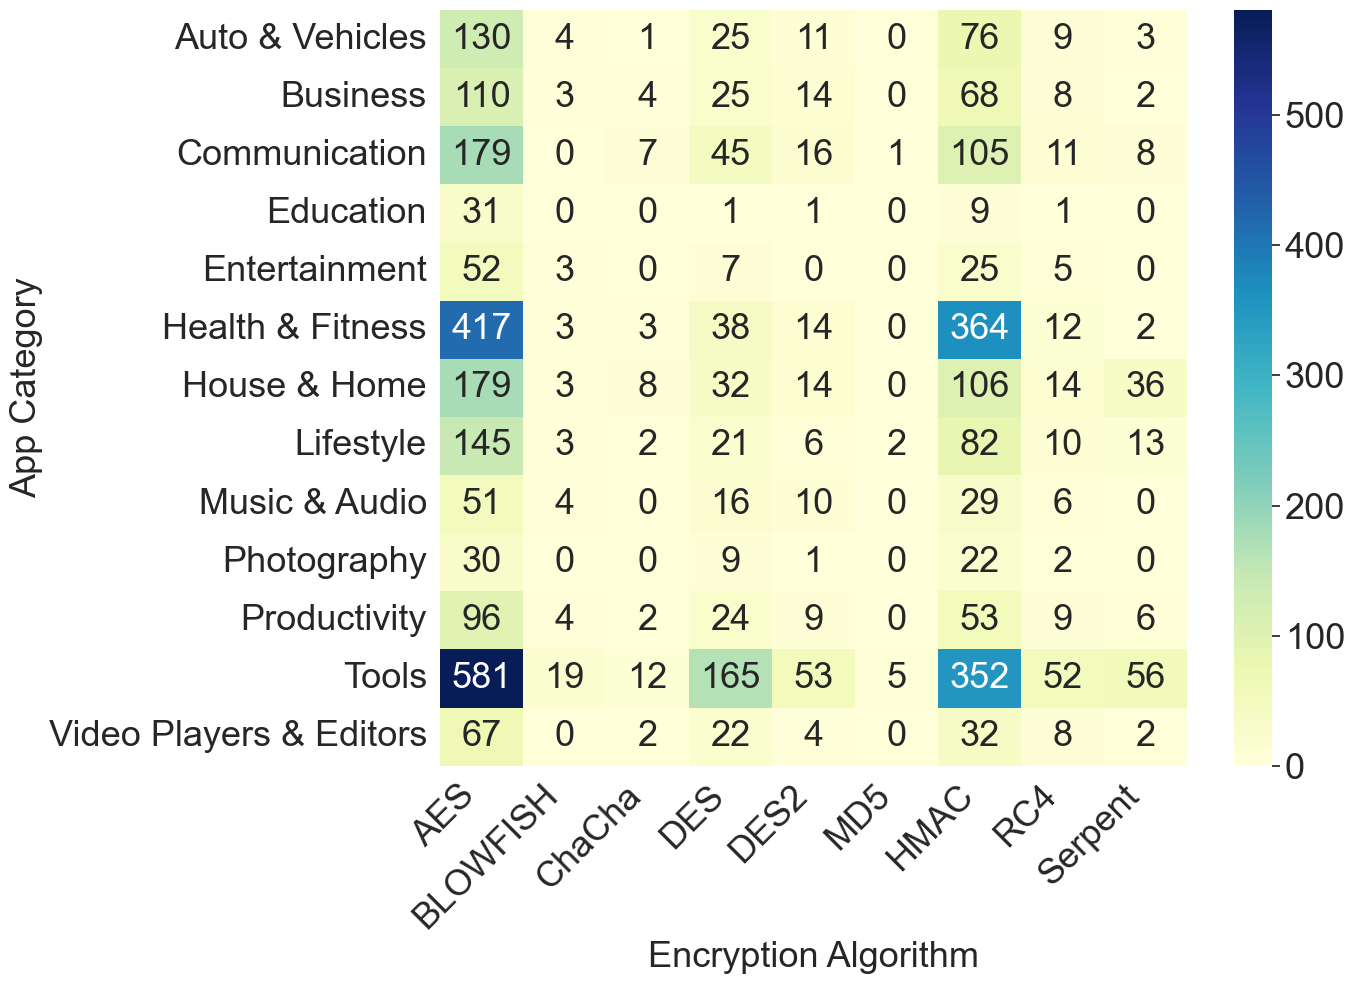


Heatmap saved as plot/vsa_crypto_heatmap_in_playstore.pdf


Crypto Ratio by Category

Auto & Vehicles: Total = 5690
  DES       :    382 (  6.71%)
  DES2      :    151 (  2.65%)
  MD5       :     11 (  0.19%)
  RC4       :    119 (  2.09%)
  BLOWFISH  :     41 (  0.72%)

Business: Total = 2743
  DES       :    224 (  8.17%)
  DES2      :    116 (  4.23%)
  MD5       :      0 (  0.00%)
  RC4       :     77 (  2.81%)
  BLOWFISH  :     35 (  1.28%)

Communication: Total = 10436
  DES       :    661 (  6.33%)
  DES2      :    201 (  1.93%)
  MD5       :     74 (  0.71%)
  RC4       :    217 (  2.08%)
  BLOWFISH  :     71 (  0.68%)

Education: Total = 467
  DES       :     10 (  2.14%)
  DES2      :      2 (  0.43%)
  MD5       :      0 (  0.00%)
  RC4       :      7 (  1.50%)
  BLOWFISH  :      2 (  0.43%)

Entertainment: Total = 931
  DES       :     50 (  5.37%)
  DES2      :     14 (  1.50%)
  MD5       :      3 (  0.32%)
  RC4       :     17 (  1.83%)
  BLOWFISH  :      1 (  0.11%)

H

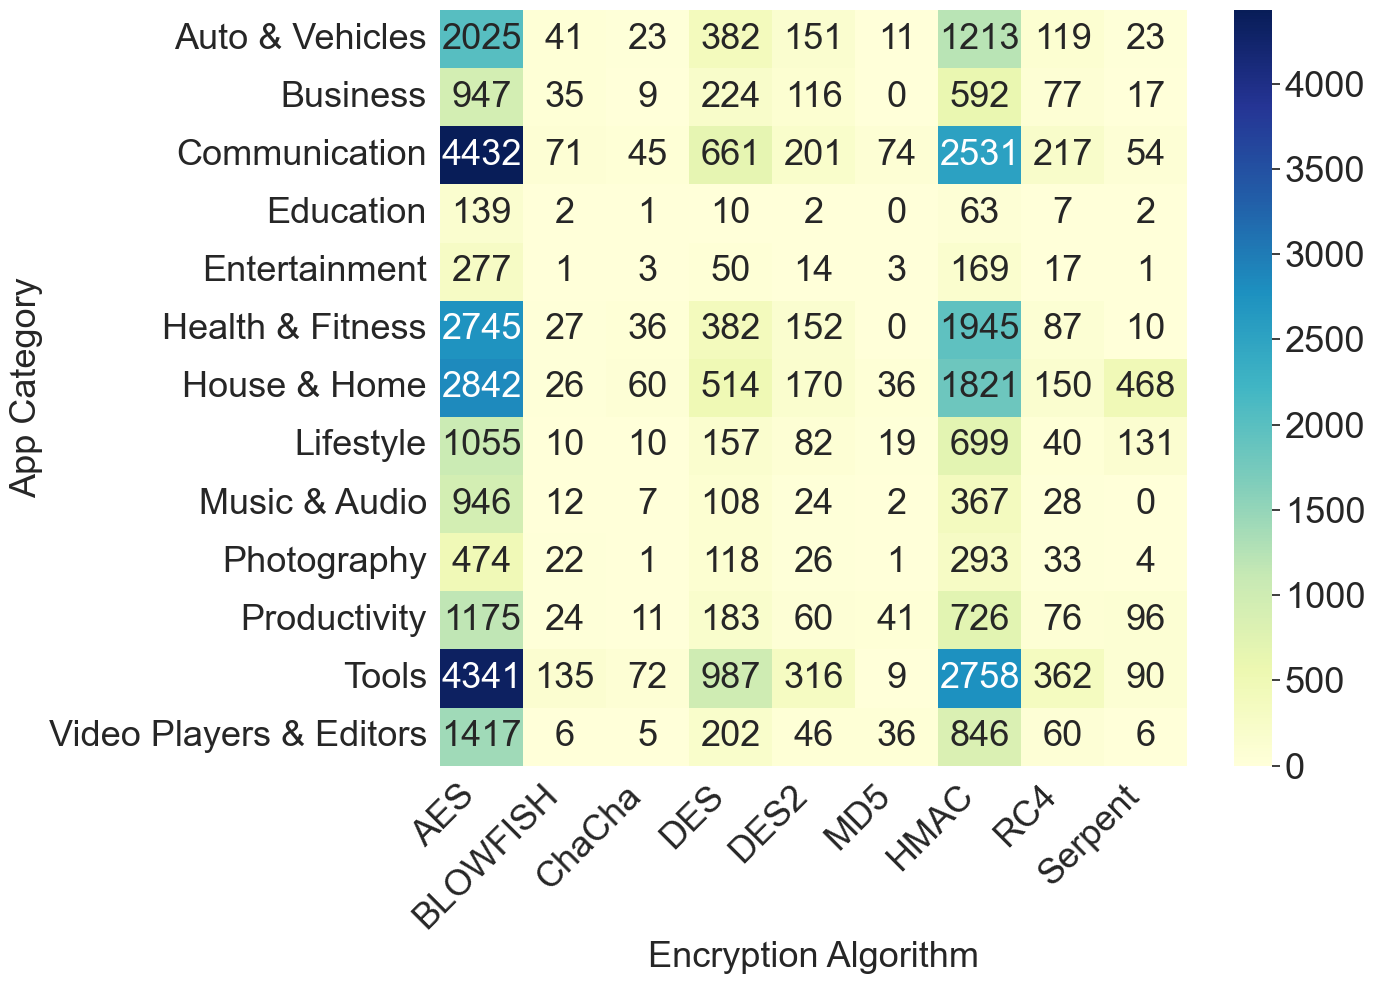


Heatmap saved as plot/vsa_crypto_heatmap_not_in_playstore.pdf


In [ ]:
def generate_heatmap(
    crypto_results_file,
    app_metadata_file,
    output_image='plot/vsa_crypto_heatmap.pdf',
    title=None
):

    font_size = 26


    crypto_targets = [
        'DES',
        'DES2',
        'MD5',
        'RC4',
        'BLOWFISH'
    ]

    # =========================================================
    # 1. Load crypto analysis results
    # =========================================================

    with open(crypto_results_file, 'r') as f:
        crypto_data = json.load(f)

    # =========================================================
    # 2. Prepare data
    # =========================================================

    heatmap_data = []


    category_crypto = {}

    for app in crypto_data.get('apps', []):

        app_id = app.get('app_name')

        category = app_metadata_file.get(app_id)

        if category:



            category_total.setdefault(
                category,
                set()
            ).add(app_id)


            algorithms = set(
                app.get('encryption_algs', [])
            )


            for crypto in crypto_targets:

                if crypto in algorithms:

                    category_crypto \
                        .setdefault(category, {}) \
                        .setdefault(crypto, set()) \
                        .add(app_id)


            for alg in algorithms:

                heatmap_data.append({
                    'Category': category,
                    'Algorithm': alg
                })

    # =========================================================
    # 3. DataFrame
    # =========================================================

    df = pd.DataFrame(heatmap_data)

    if df.empty:

        print(
            "No matching data found between "
            "crypto results and app categories."
        )

        print(
            f"Crypto apps: "
            f"{len(crypto_data.get('apps', []))}"
        )

        print(
            f"Metadata apps: "
            f"{len(app_metadata_file)}"
        )

        return

    # =========================================================
    # 4. Heatmap pivot table
    # =========================================================

    pivot_table = df.pivot_table(
        index='Category',
        columns='Algorithm',
        aggfunc='size',
        fill_value=0
    )

    # =========================================================
    # 5. Category / Algorithm
    # =========================================================

    selected_categories = [
        'Auto & Vehicles',
        'Business',
        'Communication',
        'Education',
        'Entertainment',
        'Health & Fitness',
        'House & Home',
        'Lifestyle',
        'Music & Audio',
        'Photography',
        'Productivity',
        'Tools',
        'Video Players & Editors'
    ]

    selected_algorithms = [
        'AES',
        'BLOWFISH',
        'ChaCha',
        'DES',
        'DES2',
        'MD5',
        'HMAC',
        'RC4',
        'Serpent'
    ]

    # =========================================================
    # 6. Heatmap filtering
    # =========================================================

    filtered_pivot = pivot_table.reindex(
        index=selected_categories,
        columns=selected_algorithms,
        fill_value=0
    )

    # =========================================================
    # 7. Category - Crypto Ratio
    # =========================================================

    print("\n")
    print("=" * 70)
    print("Crypto Ratio by Category")
    print("=" * 70)

    for category in selected_categories:

        total = len(
            category_total.get(category, set())
        )

        if total == 0:

            print(
                f"{category}: Total = 0"
            )

            continue

        print(
            f"\n{category}: Total = {total}"
        )

        for crypto in crypto_targets:

            crypto_count = len(
                category_crypto
                .get(category, {})
                .get(crypto, set())
            )

            crypto_ratio = (
                crypto_count / total * 100
            )

            print(
                f"  {crypto:<10}: "
                f"{crypto_count:>6} "
                f"({crypto_ratio:>6.2f}%)"
            )

    # =========================================================
    # 8. Crypto Ratio
    # =========================================================

    all_apps = set()

    for apps in category_total.values():

        all_apps.update(apps)

    overall_total = len(all_apps)

    print("\n")
    print("=" * 70)
    print("Overall Crypto Ratio")
    print("=" * 70)

    print(
        f"Total apps = {overall_total}"
    )

    # count apps that use each crypto
    overall_crypto_apps = {}

    for crypto in crypto_targets:

        crypto_apps = set()

        for category_data in category_crypto.values():

            crypto_apps.update(
                category_data.get(
                    crypto,
                    set()
                )
            )

        overall_crypto_apps[crypto] = crypto_apps

        crypto_count = len(crypto_apps)

        if overall_total > 0:

            crypto_ratio = (
                crypto_count /
                overall_total *
                100
            )

        else:

            crypto_ratio = 0

        print(
            f"{crypto:<10}: "
            f"{crypto_count:>6} "
            f"({crypto_ratio:>6.2f}%)"
        )

    # =========================================================
    # 9. apps use one of 5 Crypto 
    # =========================================================

    all_target_crypto_apps = set()

    for crypto in crypto_targets:

        all_target_crypto_apps.update(
            overall_crypto_apps[crypto]
        )

    target_crypto_count = len(
        all_target_crypto_apps
    )

    if overall_total > 0:

        target_crypto_ratio = (
            target_crypto_count /
            overall_total *
            100
        )

    else:

        target_crypto_ratio = 0

    print("\n")
    print(
        f"{'Any target crypto':<20}: "
        f"{target_crypto_count:>6} "
        f"({target_crypto_ratio:>6.2f}%)"
    )

    # =========================================================
    # 10. DES + DES2
    # =========================================================


    if 'DES' in overall_crypto_apps and \
       'DES2' in overall_crypto_apps:

        des_and_des2 = (
            overall_crypto_apps['DES']
            &
            overall_crypto_apps['DES2']
        )

        des_and_des2_count = len(
            des_and_des2
        )

        if overall_total > 0:

            des_and_des2_ratio = (
                des_and_des2_count /
                overall_total *
                100
            )

        else:

            des_and_des2_ratio = 0

        print(
            f"{'DES AND DES2':<20}: "
            f"{des_and_des2_count:>6} "
            f"({des_and_des2_ratio:>6.2f}%)"
        )

    # =========================================================
    # 11. Heatmap
    # =========================================================

    plt.figure(
        figsize=(14, 10)
    )

    sns.set_theme(
        style="white"
    )

    ax = sns.heatmap(
        filtered_pivot,
        annot=True,
        annot_kws={
            "size": font_size
        },
        fmt='d',
        cmap='YlGnBu'
    )

    # Colorbar font size
    cbar = ax.collections[0].colorbar

    cbar.ax.tick_params(
        labelsize=font_size
    )

    # Title
    if title:

        plt.title(
            title,
            fontsize=font_size
        )

    # Axis labels
    plt.xlabel(
        'Encryption Algorithm',
        fontsize=font_size
    )

    plt.ylabel(
        'App Category',
        fontsize=font_size
    )

    # Tick labels
    plt.xticks(
        rotation=45,
        ha='right',
        fontsize=font_size
    )

    plt.yticks(
        rotation=0,
        fontsize=font_size
    )

    plt.tight_layout()

    # =========================================================
    # 12. Save heatmap
    # =========================================================

    plt.savefig(
        output_image,
        bbox_inches='tight'
    )

    plt.show()

    print(
        f"\nHeatmap saved as {output_image}"
    )


# =============================================================
# Main
# =============================================================

if __name__ == "__main__":

    # ---------------------------------------------------------
    # 1. Play Store
    # ---------------------------------------------------------

    generate_heatmap(
        'vsa-crypto-analysis-result.json',
        category_dict_from_playstore,
        output_image=(
            'plot/'
            'vsa_crypto_heatmap_in_playstore.pdf'
        ),
        # title='In Play Store',
    )

    # ---------------------------------------------------------
    # 2. not in Play Store
    # ---------------------------------------------------------

    generate_heatmap(
        'vsa-crypto-analysis-result.json',
        category_dict_not_in_playstore,
        output_image=(
            'plot/'
            'vsa_crypto_heatmap_not_in_playstore.pdf'
        ),
        # title='Not in Play Store',
    )
